<a href="https://colab.research.google.com/github/riya-git29/Freelancer-Portfolio/blob/main/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   User_ID  Cust_name Product_ID Gender Age Group  Age  Marital_Status  \
0  1002903  Sanskriti  P00125942      F     26-35   28               0   
1  1000732     Kartik  P00110942      F     26-35   35               1   
2  1001990      Bindu  P00118542      F     26-35   35               1   
3  1001425     Sudevi  P00237842      M      0-17   16               0   
4  1000588       Joni  P00057942      M     26-35   28               1   

            State      Zone       Occupation Product_Category  Orders  \
0     Maharashtra   Western       Healthcare             Auto       1   
1  Andhra Pradesh  Southern             Govt             Auto       3   
2   Uttar Pradesh   Central       Automobile             Auto       3   
3       Karnataka  Southern     Construction             Auto       2   
4         Gujarat   Western  Food Processing             Auto       2   

    Amount  Status  unnamed1  
0  23952.0     NaN       NaN  
1  23934.0     NaN       NaN  
2  23924.0     NaN     

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

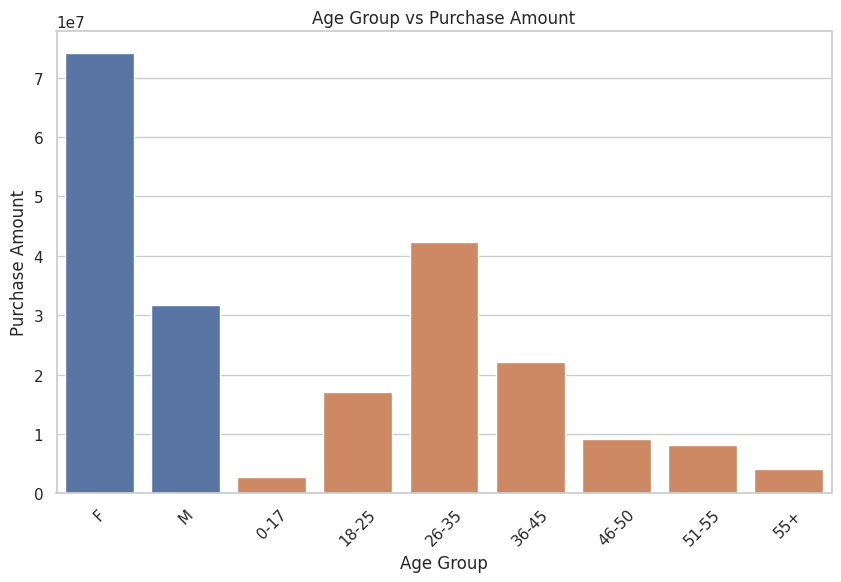

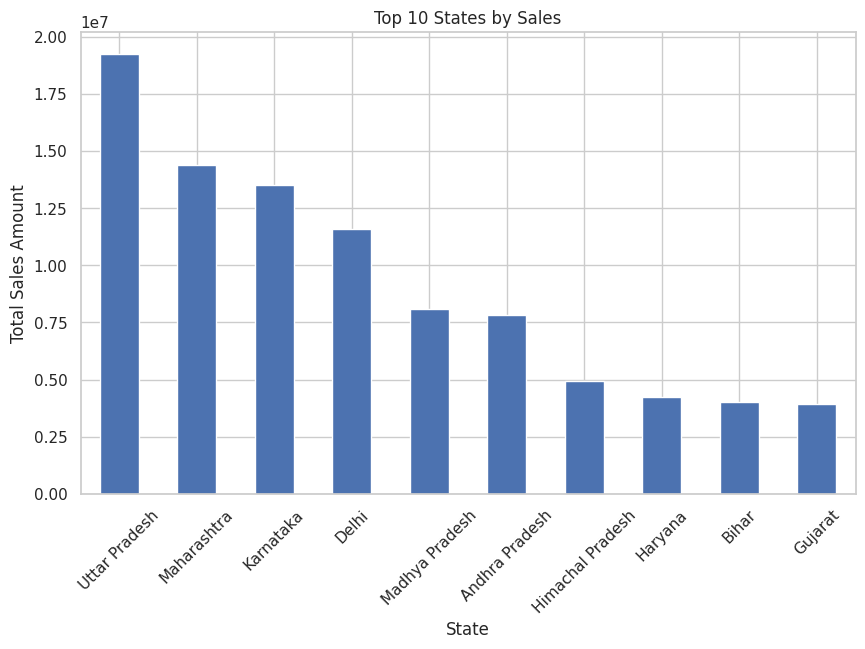

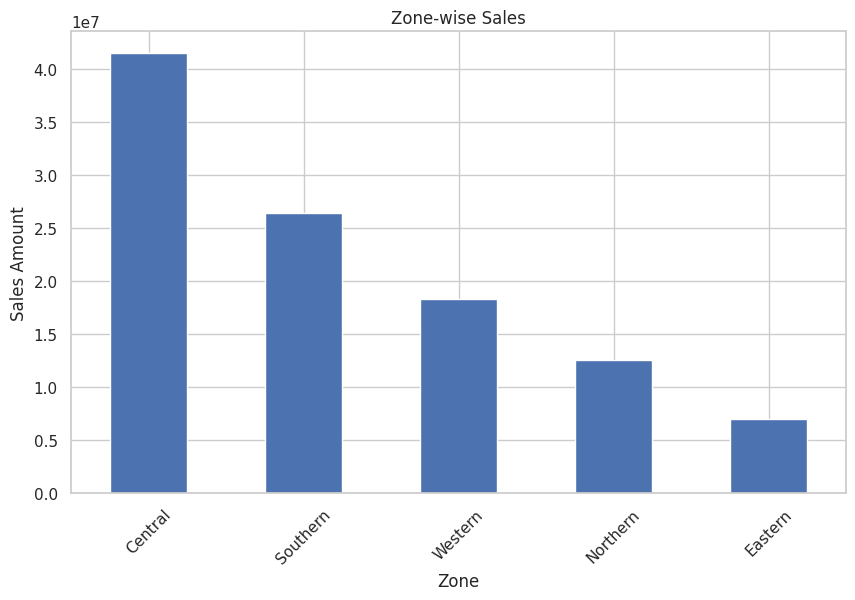

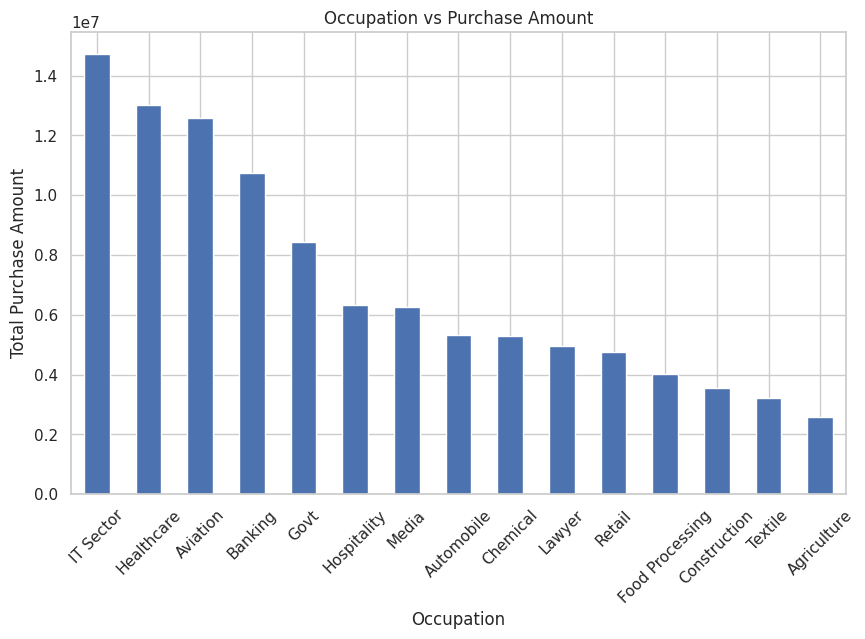

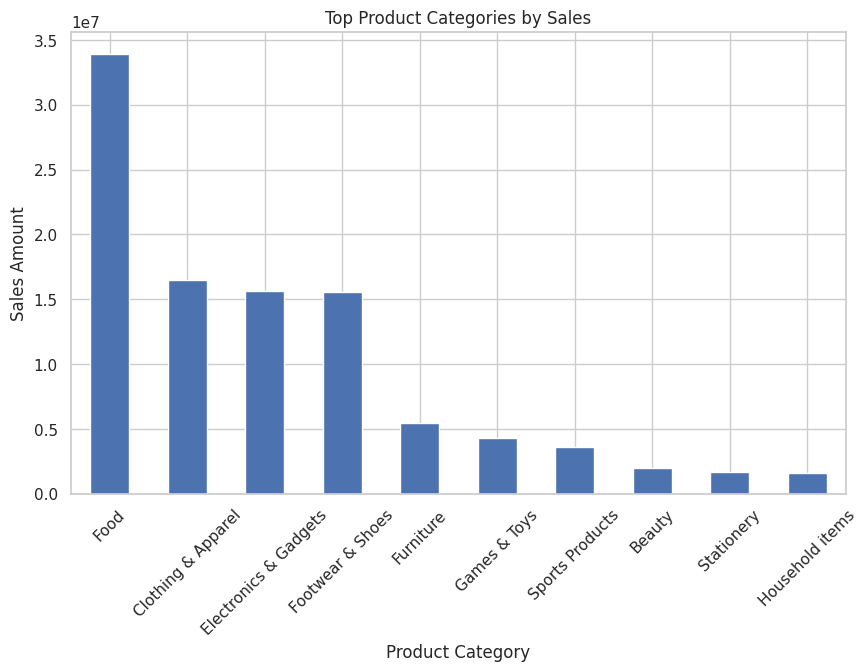

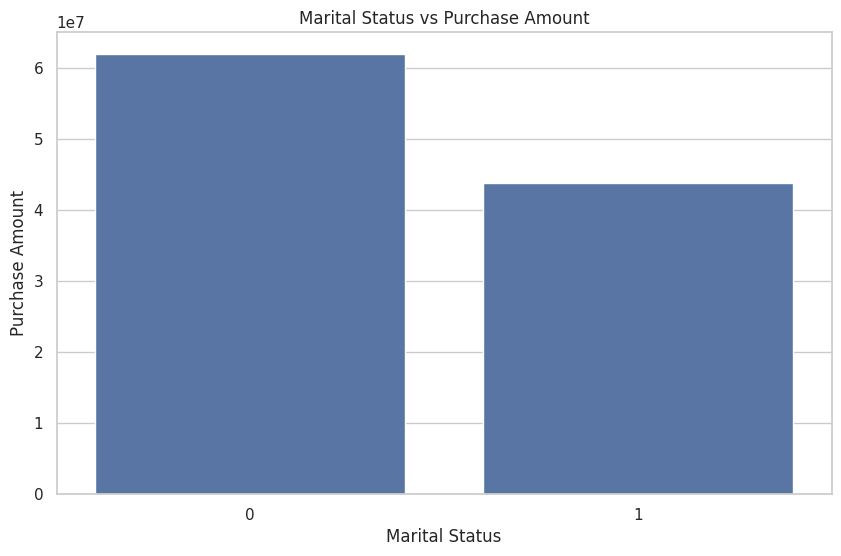

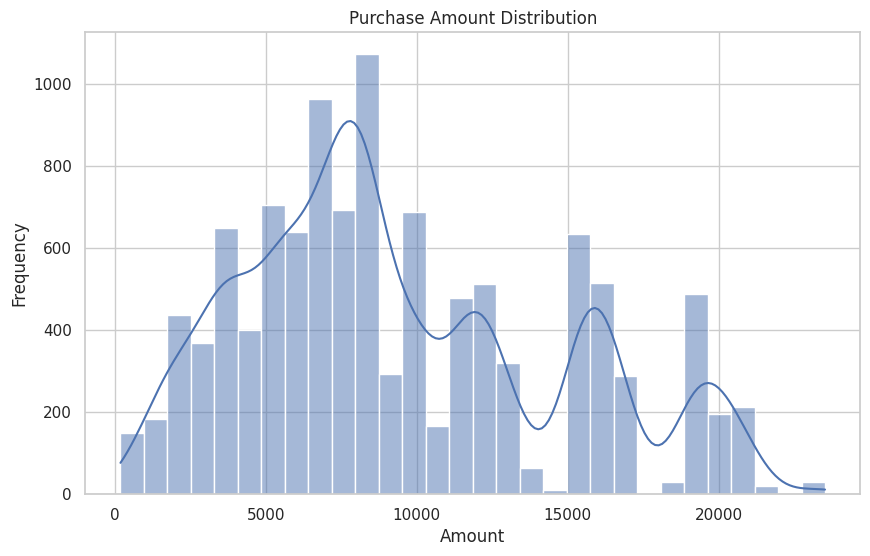

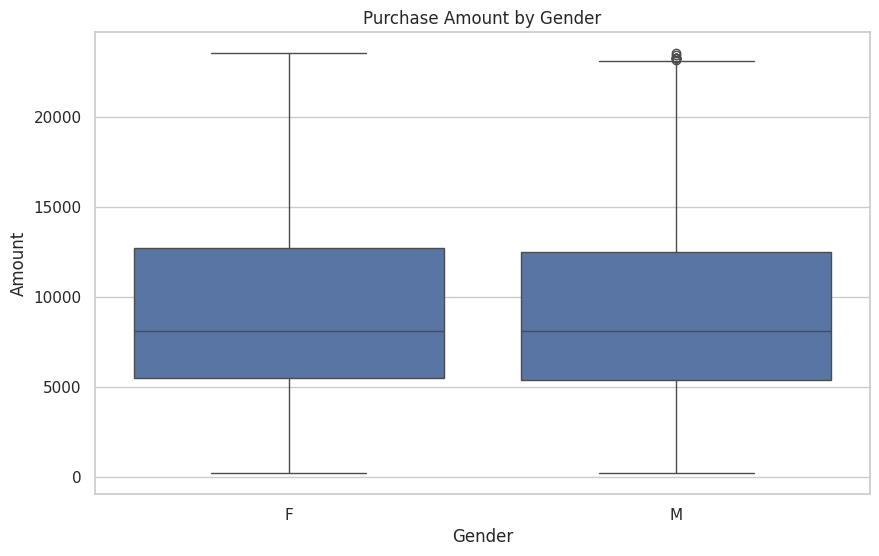

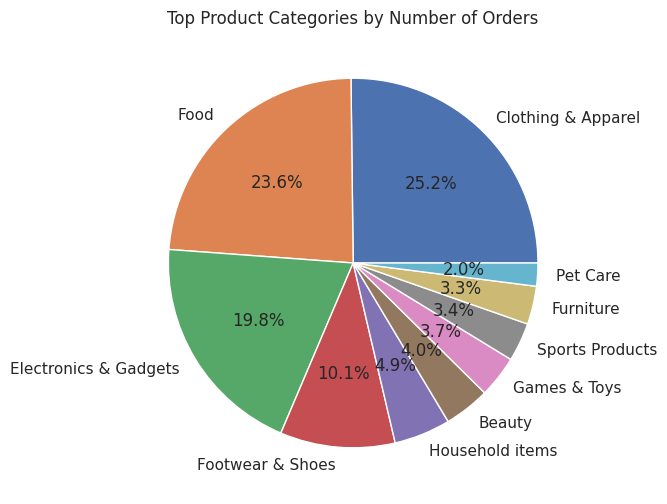

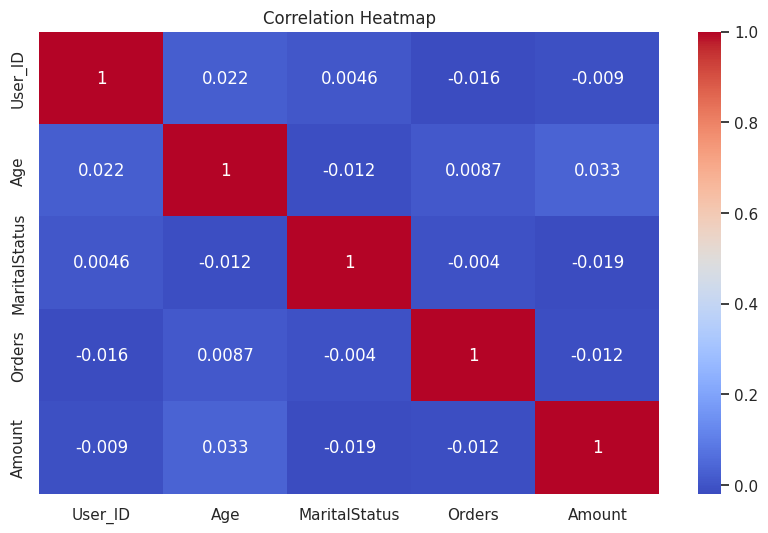

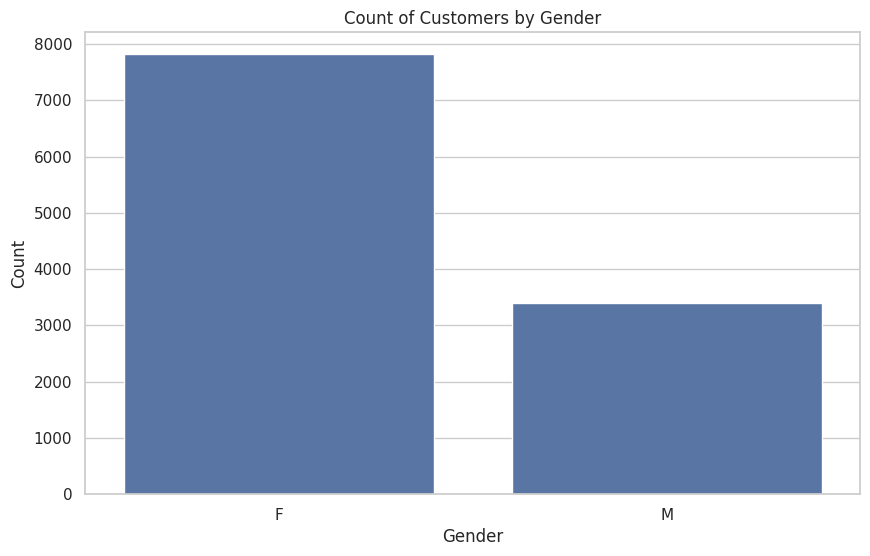

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load Dataset
df = pd.read_csv('Diwali Sales Data.csv', encoding='unicode_escape')

# Display First 5 Rows
print(df.head())

# Dataset Information
print(df.info())

# Check Shape
print(df.shape)

# Check Column Names
print(df.columns)

# Remove Unnecessary Columns
if 'Status' in df.columns:
    df.drop(['Status'], axis=1, inplace=True)

if 'unnamed1' in df.columns:
    df.drop(['unnamed1'], axis=1, inplace=True)

# Check Missing Values
print(df.isnull().sum())

# Remove Missing Values
df.dropna(inplace=True)

# Rename Columns
rename_dict = {}

if 'Marital_Status' in df.columns:
    rename_dict['Marital_Status'] = 'MaritalStatus'

if 'Product_ID' in df.columns:
    rename_dict['Product_ID'] = 'ProductID'

if 'Product_Category' in df.columns:
    rename_dict['Product_Category'] = 'ProductCategory'

df.rename(columns=rename_dict, inplace=True)

# Remove Duplicate Rows
df.drop_duplicates(inplace=True)

# Convert Amount Column to Numeric
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

# Remove Null Values Again
df.dropna(inplace=True)

# Convert Amount to Integer
df['Amount'] = df['Amount'].astype(int)

# Remove Outliers Using IQR Method
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Amount'] >= lower_bound) & (df['Amount'] <= upper_bound)]

# Final Shape
print(df.shape)

# Save Cleaned Dataset
df.to_csv('diwali_cleaned.csv', index=False)

# -------------------------------
# Exploratory Data Analysis (EDA)
# -------------------------------

# 1. Gender-wise Purchase
gender_sales = df.groupby('Gender')['Amount'].sum().reset_index()

sns.barplot(x='Gender', y='Amount', data=gender_sales)
files.download('diwali_cleaned.csv')


# 2. Age Group vs Purchase Amount
age_sales = df.groupby('Age Group')['Amount'].sum().reset_index()

sns.barplot(x='Age Group', y='Amount', data=age_sales)
plt.title('Age Group vs Purchase Amount')
plt.xlabel('Age Group')
plt.ylabel('Purchase Amount')
plt.xticks(rotation=45)
plt.show()

# 3. Top 10 States by Sales
state_sales = df.groupby('State')['Amount'].sum().sort_values(ascending=False).head(10)

state_sales.plot(kind='bar')
plt.title('Top 10 States by Sales')
plt.xlabel('State')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.show()

# 4. Zone-wise Sales
zone_sales = df.groupby('Zone')['Amount'].sum().sort_values(ascending=False)

zone_sales.plot(kind='bar')
plt.title('Zone-wise Sales')
plt.xlabel('Zone')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.show()


# 5. Occupation vs Purchase
occupation_sales = df.groupby('Occupation')['Amount'].sum().sort_values(ascending=False)

occupation_sales.plot(kind='bar')
plt.title('Occupation vs Purchase Amount')
plt.xlabel('Occupation')
plt.ylabel('Total Purchase Amount')
plt.xticks(rotation=45)
plt.show()

# 6. Product Category Popularity
category_sales = df.groupby('ProductCategory')['Amount'].sum().sort_values(ascending=False).head(10)

category_sales.plot(kind='bar')
plt.title('Top Product Categories by Sales')
plt.xlabel('Product Category')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.show()

# 7. Marital Status vs Purchase
marital_sales = df.groupby('MaritalStatus')['Amount'].sum().reset_index()

sns.barplot(x='MaritalStatus', y='Amount', data=marital_sales)
plt.title('Marital Status vs Purchase Amount')
plt.xlabel('Marital Status')
plt.ylabel('Purchase Amount')
plt.show()

# 8. Purchase Amount Distribution
sns.histplot(df['Amount'], bins=30, kde=True)
plt.title('Purchase Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

# 9. Boxplot: Purchase by Gender
sns.boxplot(x='Gender', y='Amount', data=df)
plt.title('Purchase Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Amount')
plt.show()

# 10. Orders by Product Category
product_orders = df['ProductCategory'].value_counts().head(10)

product_orders.plot(kind='pie', autopct='%1.1f%%')
plt.title('Top Product Categories by Number of Orders')
plt.ylabel('')
plt.show()

# 11. Correlation Heatmap
numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


# 12. Gender Count Plot
sns.countplot(x='Gender', data=df)
plt.title('Count of Customers by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

# Download Cleaned CSV File in Google Colab
from google.colab import files
files.download('diwali_cleaned.csv')